Date: 14/11/2024 <br>
Desc: To test for independence of gamma between different downlinks and between uplink and downlink.

In [1]:
import pandas as pd
import numpy as np 
import os
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

## On Dataset

### Load Compiled Data and Sort

In [8]:
dataset_path = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_{}_processed.csv"

ul_df = pd.read_csv(dataset_path.format("ul"))
ul_df = ul_df.loc[ul_df["Time"]>=1]
ul_df.sort_values(by=["UAV_Speed", "UAV_Height", "Bit_Rate", "USI", "Time"], inplace=True)

gw_dl_df = pd.read_csv(dataset_path.format("UAV_0"))
gw_dl_df = gw_dl_df.loc[gw_dl_df["Time"]>=1]
gw_dl_df.sort_values(by=["UAV_Speed", "UAV_Height", "Bit_Rate", "USI", "Time"], inplace=True)

uav1_dl_df = pd.read_csv(dataset_path.format("UAV_1"))
uav1_dl_df = uav1_dl_df.loc[uav1_dl_df["Time"]>=1]
uav1_dl_df.sort_values(by=["UAV_Speed", "UAV_Height", "Bit_Rate", "USI", "Time"], inplace=True)

### Correlation Test

In [9]:
# Spearman Correlation
spearmanr_ul_gw = stats.spearmanr(ul_df["Num_Reliable"].values, gw_dl_df["Num_Reliable"].values)
spearmanr_uav1_gw = stats.spearmanr(uav1_dl_df["Num_Reliable"].values, gw_dl_df["Num_Reliable"].values)
print(spearmanr_ul_gw, spearmanr_uav1_gw)
# Kendall Tau Correlation
kendallt_ul_gw = stats.kendalltau(ul_df["Num_Reliable"].values, gw_dl_df["Num_Reliable"].values)
kendallt_uav1_gw = stats.kendalltau(uav1_dl_df["Num_Reliable"].values, gw_dl_df["Num_Reliable"].values)
print(kendallt_ul_gw, kendallt_uav1_gw)


SpearmanrResult(correlation=0.4054309390019261, pvalue=0.0) SpearmanrResult(correlation=0.9813474829821678, pvalue=0.0)


/home/research-student/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4868: RuntimeWarning: overflow encountered in long_scalars
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


KendalltauResult(correlation=0.3411731778254214, pvalue=0.0) KendalltauResult(correlation=0.9776694430222883, pvalue=0.0)


### Mutual Information

In [11]:
mi_ul_gw = mutual_info_regression(ul_df["Num_Reliable"].values.reshape(-1, 1), gw_dl_df["Num_Reliable"].values)
mi_uav1_gw = mutual_info_regression(uav1_dl_df["Num_Reliable"].values.reshape(-1, 1), gw_dl_df["Num_Reliable"].values)
print(mi_ul_gw, mi_uav1_gw)

[0.02999169] [0.56879541]


### Plot X against Y

Text(0.5, 0, 'Uplink UAV 2 $\\gamma$')

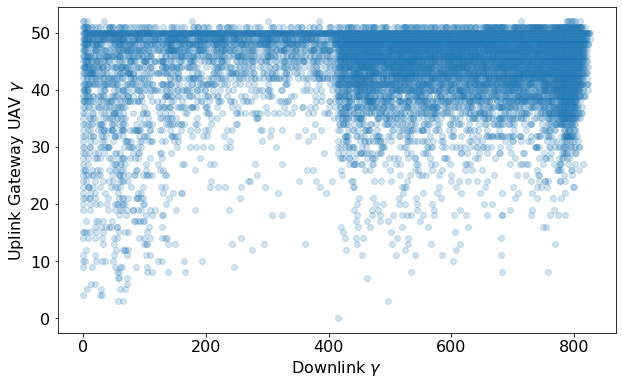

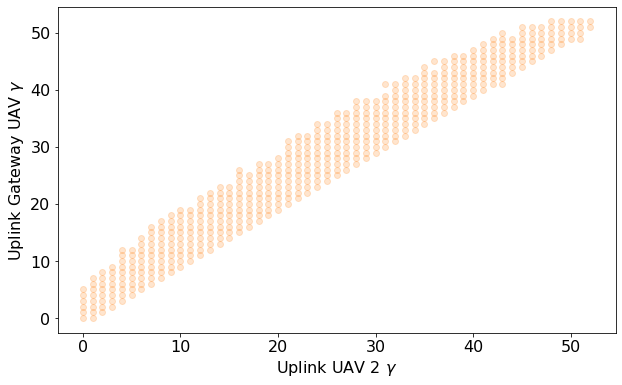

In [33]:
import matplotlib.pyplot as plt

ul_gw_df = pd.DataFrame({"UL_Num_Reliable": ul_df["Num_Reliable"],
                         "GW_Num_Reliable": gw_dl_df["Num_Reliable"],
                         "USI": ul_df["USI"]})
ul_gw_df.drop_duplicates(subset=["UL_Num_Reliable", "GW_Num_Reliable"], inplace=True)

uav1_gw_df = pd.DataFrame({"GW_Num_Reliable": gw_dl_df["Num_Reliable"],
                         "UAV_1_Num_Reliable": uav1_dl_df["Num_Reliable"]})
uav1_gw_df.drop_duplicates(subset=["UAV_1_Num_Reliable", "GW_Num_Reliable"], inplace=True)

temp = ul_gw_df.loc[ul_gw_df["USI"]==10]

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 16})
plt.scatter(temp["UL_Num_Reliable"], temp["GW_Num_Reliable"], c="tab:blue", alpha=0.2, linewidths=1)
plt.ylabel("Uplink Gateway UAV $\\gamma$")
plt.xlabel("Downlink $\\gamma$")
# plt.xlim(left=0)
# plt.ylim((0,1.05))

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 16})
plt.scatter(uav1_gw_df["UAV_1_Num_Reliable"], uav1_gw_df["GW_Num_Reliable"], c="tab:orange", alpha=0.2, linewidths=1)
plt.ylabel("Uplink Gateway UAV $\\gamma$")
plt.xlabel("Uplink UAV 2 $\\gamma$")
# plt.xlim(left=0)
# plt.ylim((0,1.05))

## On Sample Independent Variables (Normal and Uniform)

In [23]:
n = 100000 # No. samples

# Gaussian
# X = np.random.normal(loc=0,scale=1,size=(1,n))
# Y = np.random.normal(loc=0,scale=1,size=(1,n))

# Uniform 
X = np.random.rand(n)
Y = np.random.rand(n)

In [24]:
# Spearman Correlation
spearmanr_XY = stats.spearmanr(X, Y)
# Kendall Tau Correlation
kendallt_XY = stats.kendalltau(X, Y)
print(spearmanr_XY, kendallt_XY)

SpearmanrResult(correlation=0.007704967733150497, pvalue=0.014828921326419081) KendalltauResult(correlation=0.005136582965829659, pvalue=0.014832113360932136)


In [25]:
# Mutual Information
mi_XY = mutual_info_regression(X.reshape(-1, 1), Y.reshape(n, ))
print(mi_XY)

[0]


Text(0.5, 0, 'X')

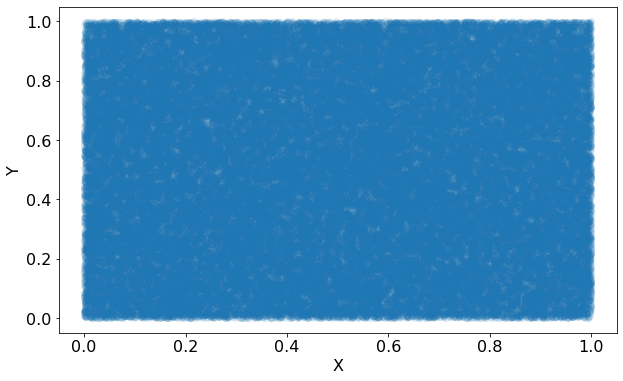

In [27]:
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 16})
plt.scatter(X, Y, c="tab:blue", alpha=0.1, linewidths=1)
plt.ylabel("Y")
plt.xlabel("X")